# Summative Lab – Analytics Firm Clients: Customer Reviews Analysis

This notebook is a **starter notebook** for the three parts of the lab:

1. NLP  
2. Time Series  
3. Neural Networks  

Use the comments and TODO prompts to guide your work. The notebook is intentionally incomplete so you can implement the analysis yourself.


## Part 1: NLP

In this section, you will clean and preprocess review text, explore frequent words and bigrams, and visualize key language patterns in the dataset.


Part 1: NLP Starter Code

Import the libraries

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer,PorterStemmer
from nltk.tokenize import word_tokenize, sent_tokenize

# Counting
from collections import Counter
from nltk.util import ngrams

Download NLTK resources

In [4]:
nltk.download('punkt')
nltk.download('punkt_tab')      # needed for newer NLTK versions
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /home/magical/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/magical/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/magical/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/magical/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/magical/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/magical/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/magical/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger

True

In [7]:
# For dataset loading
from sklearn.datasets import fetch_20newsgroups


# Set random seed for reproducibility
np.random.seed(42)


Load the dataset

In [12]:
df = pd.read_csv("amazon_reviews_lab.csv")
df.head()

,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,This film is definitely not for anyone who is ...,The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,2000-05-12,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hal...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,2002-08-26,positive,168
2,6301977173,1,I would love to buy this movie as I have been ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,2005-08-06,negative,60
3,6301977173,1,The advertisment for this DVD on Amazon was in...,False advertising on this DVD,"09 11, 2005",1.126397e+09,2005-09-11,negative,104
4,9575871979,5,I bought some of these to try with a light usi...,Work GREAT!!,"10 15, 2007",1.192406e+09,2007-10-15,positive,60


Explore the dataset

In [13]:
print(df.shape)


(997, 9)


In [17]:

print(df["rating"].value_counts().sort_index())


rating
1     87
2     48
3     94
4    188
5    580
Name: count, dtype: int64


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           997 non-null    object 
 1   rating               997 non-null    int64  
 2   review_text          997 non-null    object 
 3   review_summary       997 non-null    object 
 4   review_time_raw      997 non-null    object 
 5   unix_review_time     997 non-null    float64
 6   timestamp            997 non-null    object 
 7   sentiment_label      997 non-null    object 
 8   review_length_words  997 non-null    int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 70.2+ KB


In [16]:
df.isnull().sum()

product_id             0
rating                 0
review_text            0
review_summary         0
review_time_raw        0
unix_review_time       0
timestamp              0
sentiment_label        0
review_length_words    0
dtype: int64

Convert timestamp to datetime

Since the timestamp is an object we need to convert it to datatime 

In [19]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [21]:
df["timestamp"].dtype

dtype('<M8[ns]')

In [22]:
df[["rating", "review_text"]].head()

,rating,review_text
0,2,This film is definitely not for anyone who is ...
1,5,This movie was playing at Radio City Music Hal...
2,1,I would love to buy this movie as I have been ...
3,1,The advertisment for this DVD on Amazon was in...
4,5,I bought some of these to try with a light usi...


Create preprocessing tools

stopwords and Lemmatizer

In [24]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

Create a function called preprocess_text(text) that, respectively:
 1. converts text to lowercase
 2. removes URLs
 3. removes punctuation
 4. tokenizes the text
 5. keeps alphabetic tokens only
 6. removes stopwords
 7. lemmatizes the remaining tokens
 8. returns the cleaned tokens

In [30]:
def preprocess_text(text):
    text = str(text).lower()
    
    text = re.sub(r'http\S+|www\. \S+', '',text)
    
    text = text.translate(str.maketrans('', '',string.punctuation))
    
    tokens = word_tokenize(text)
    
    tokens = [token for token in tokens if token.isalpha()]
    
    tokens = [token for token in tokens if token not in stop_words]
    
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return tokens 



In [31]:
review1 = df["review_text"].iloc[0]

print("Orginal\n", review1[:500])

print("----------------------------")

print("Processsed\n", preprocess_text(review1)[:30])


Orginal
 This film is definitely not for anyone who is especially fond of the independent, delightfully manipulative and clever boy who was the brain child of Samuel Clemens's classic.As one example, the book has great fun with the scenes involving Aunt Polly, a simple minded soul who thinks herself quite clever, and the genuinely shrewd Tom, who plays on catering to Polly's illusions about her own wit. This is a far cry from beautiful, intelligent Celeste Holm's portrayal of Polly - and the family's pov
----------------------------
Processsed
 ['film', 'definitely', 'anyone', 'especially', 'fond', 'independent', 'delightfully', 'manipulative', 'clever', 'boy', 'brain', 'child', 'samuel', 'clemens', 'classicas', 'one', 'example', 'book', 'great', 'fun', 'scene', 'involving', 'aunt', 'polly', 'simple', 'minded', 'soul', 'think', 'quite', 'clever']


Apply your preprocessing function to the review text column and and store the output in a new column such as 'processed_tokens

In [33]:
df["processed_tokens"] =  df["review_text"].apply(preprocess_text)
df[["review_text", "processed_tokens"]].head()

,review_text,processed_tokens
0,This film is definitely not for anyone who is ...,"[film, definitely, anyone, especially, fond, i..."
1,This movie was playing at Radio City Music Hal...,"[movie, playing, radio, city, music, hall, bac..."
2,I would love to buy this movie as I have been ...,"[would, love, buy, movie, hannibal, missouri, ..."
3,The advertisment for this DVD on Amazon was in...,"[advertisment, dvd, amazon, incorrect, ad, sta..."
4,I bought some of these to try with a light usi...,"[bought, try, light, using, work, advertised, ..."


Combine all tokens into one list so you can compute word frequencies.


In [41]:
combined_tokens = []

for tokens in df["processed_tokens"]:
    combined_tokens.extend(tokens)
    
print("Total tokens is:", len(combined_tokens))   
print("Unique tokens is:", len(set(combined_tokens)))  
    
# token for tokens in df["processed_token"] for token in tokens]

Total tokens is: 72140
Unique tokens is: 8587


Identify the most common words using Counter


In [58]:
common_words = Counter(combined_tokens)
the_top_words = common_words.most_common(25)

the_top_words

[('nook', 1509),
 ('book', 913),
 ('one', 569),
 ('kindle', 561),
 ('screen', 496),
 ('like', 459),
 ('read', 454),
 ('work', 446),
 ('get', 424),
 ('great', 422),
 ('use', 420),
 ('tablet', 419),
 ('tv', 416),
 ('device', 381),
 ('would', 378),
 ('good', 330),
 ('bn', 321),
 ('time', 318),
 ('also', 317),
 ('well', 305),
 ('mount', 303),
 ('reading', 282),
 ('card', 280),
 ('price', 277),
 ('bought', 276)]

In [59]:
top_words= [words[0] for words in the_top_words]

top_words


['nook',
 'book',
 'one',
 'kindle',
 'screen',
 'like',
 'read',
 'work',
 'get',
 'great',
 'use',
 'tablet',
 'tv',
 'device',
 'would',
 'good',
 'bn',
 'time',
 'also',
 'well',
 'mount',
 'reading',
 'card',
 'price',
 'bought']

visualization of the most common words.

/tmp/ipykernel_9826/3283751628.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


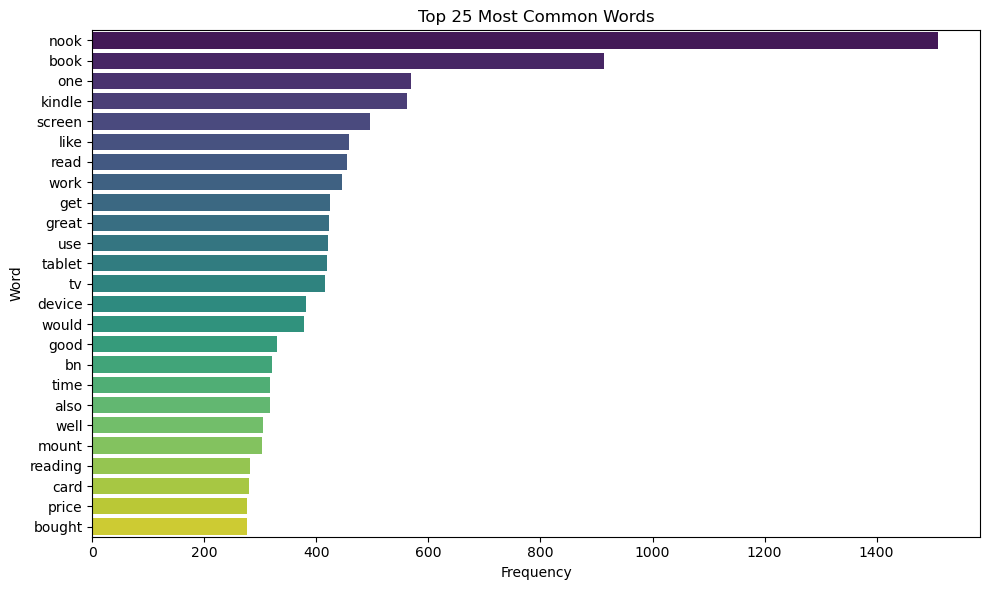

In [61]:
words, counts = zip(*the_top_words)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Top 25 Most Common Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

Generate bigrams from the token list and identify the most common bigrams

In [68]:
bigrams = list(ngrams(combined_tokens, 2))
bigrams_counts = Counter(bigrams)
top_bigrams = bigrams_counts.most_common(25)

top_bigrams

[(('barnes', 'noble'), 152),
 (('nook', 'color'), 127),
 (('battery', 'life'), 87),
 (('touch', 'screen'), 81),
 (('sd', 'card'), 80),
 (('nook', 'hd'), 74),
 (('work', 'great'), 63),
 (('nook', 'tablet'), 63),
 (('work', 'well'), 57),
 (('read', 'book'), 55),
 (('kindle', 'fire'), 55),
 (('wall', 'mount'), 51),
 (('simple', 'touch'), 44),
 (('android', 'tablet'), 39),
 (('customer', 'service'), 38),
 (('nook', 'simple'), 37),
 (('bn', 'store'), 35),
 (('easy', 'install'), 34),
 (('original', 'nook'), 34),
 (('ebook', 'reader'), 33),
 (('work', 'fine'), 32),
 (('google', 'play'), 32),
 (('page', 'turn'), 31),
 (('credit', 'card'), 31),
 (('free', 'book'), 31)]

In [65]:
top_bigrams_str = [(' '.join(bg), c) for bg, c in top_bigrams]
top_bigrams_str

[('barnes noble', 152),
 ('nook color', 127),
 ('battery life', 87),
 ('touch screen', 81),
 ('sd card', 80),
 ('nook hd', 74),
 ('work great', 63),
 ('nook tablet', 63),
 ('work well', 57),
 ('read book', 55),
 ('kindle fire', 55),
 ('wall mount', 51),
 ('simple touch', 44),
 ('android tablet', 39),
 ('customer service', 38),
 ('nook simple', 37),
 ('bn store', 35),
 ('easy install', 34),
 ('original nook', 34),
 ('ebook reader', 33),
 ('work fine', 32),
 ('google play', 32),
 ('page turn', 31),
 ('credit card', 31),
 ('free book', 31)]

visualization of the most common words.



/tmp/ipykernel_9826/1877081918.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(bg_counts), y=list(bg_labels), palette='magma')


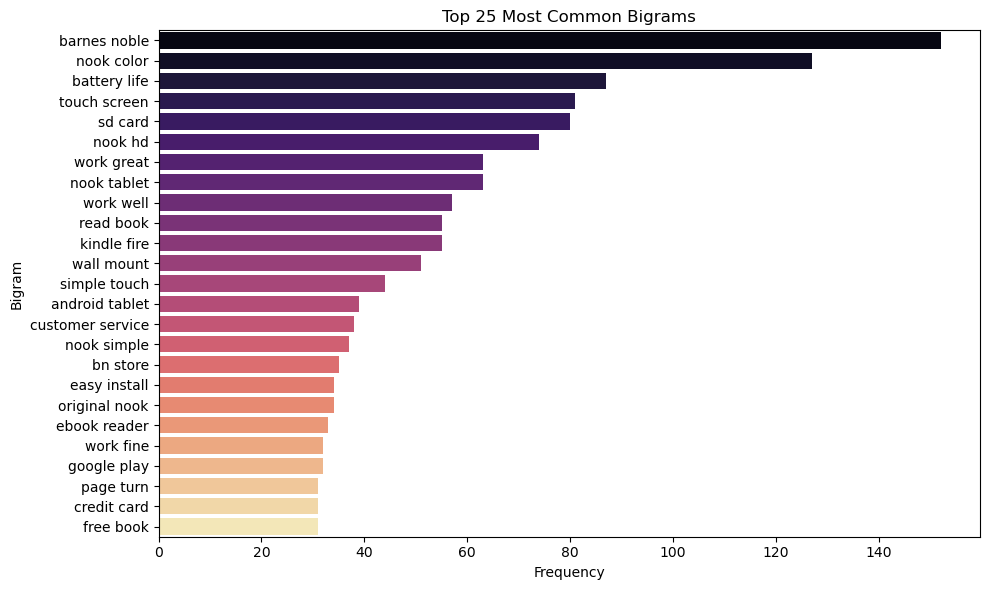

In [66]:
bg_labels, bg_counts = zip(*top_bigrams_str)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(bg_counts), y=list(bg_labels), palette='magma')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()

Reflection prompt

## Part 2: Time Series

In this section, you will analyze review activity over time by converting timestamps, resampling the data, and visualizing trends in review volume and ratings.


Import the libraries

In [ ]:


# TODO:  you need.

# TODO: Load the same review dataset.
# df = ...

# TODO: Convert the timestamp column to datetime format.

# TODO: Inspect the date range in the dataset.
# Suggested checks:
# - earliest timestamp
# - latest timestamp

# TODO: Resample the data by month to calculate:
# 1. monthly review count
# 2. monthly average rating

# Suggested variable names:
# monthly_review_count = ...
# monthly_avg_rating = ...

# TODO: Plot monthly review volume over time.

# TODO: Plot average monthly rating over time.

# TODO: Compute a rolling average for the monthly average rating.
# A 3-month rolling average is a good starting point.

# TODO: Plot both:
# - the original monthly average rating
# - the rolling average
# on the same figure.

# Reflection prompt:
# What overall trends do you notice in review activity and customer ratings over time?


## Part 3: Neural Networks

In this section, you will transform text reviews into numerical features, train a neural network to predict ratings, and evaluate model performance.


In [ ]:
# ===================================
# Part 3: Neural Networks Starter Code
# ===================================

# TODO: Import the libraries you need for:
# - data handling
# - train/test splitting
# - text vectorization
# - model building
# - model evaluation

# You will likely need tools from:
# - pandas / numpy
# - sklearn
# - tensorflow / keras

# TODO: Load the dataset.
# df = ...

# TODO: Define:
# X as the review text column
# y as the rating column
# If needed, adjust y so the classes are numbered appropriately for your model.

# TODO: Vectorize the text using TF-IDF.
# Suggested question:
# - How many features do you want to keep?

# vectorizer = ...
# X_tfidf = ...

# TODO: Split the data into training and testing sets.
# Use stratify=y to preserve class balance.

# TODO: One-hot encode the target values if your neural network setup requires it.

# TODO: Build a neural network model.
# Include:
# - an input layer
# - at least one hidden layer
# - an output layer suitable for multi-class classification

# model = ...

# TODO: Compile the model.
# Think about:
# - optimizer
# - loss function
# - evaluation metric(s)

# TODO: Train the model and store the training history.
# history = ...

# TODO: Evaluate the model on the test set.

# TODO: Generate predictions on the test set.

# TODO: Create a classification report and/or confusion matrix to assess performance.

# Reflection prompt:
# Which rating classes does the model predict well, and which ones are harder to classify?
